# SOLA Method — Realistic Earth Demo

This notebook is a **direct counterpart of `sola_demo.ipynb`** with two changes:

1. **Domain**: $[0, 6371]$ km (radius from Earth centre to surface).
2. **Sensitivity kernels**: real seismic $v_p$ sensitivity kernels loaded from
   `kernels_modeplotaat_Adrian` via `kernel_utils.SensitivityKernelProvider`.

Everything else — unimodular SOLA construction, 20-cell boxcar discretization,
export to `sola-base` and comparison — is identical to the synthetic demo.

In [1]:
import sys
from pathlib import Path

_demo_dir = Path('/home/adrian/PhD/Inferences/intervalinf/demos/sola-base_demo')
if str(_demo_dir) not in sys.path:
    sys.path.insert(0, str(_demo_dir))

from kernel_utils import (
    SensitivityKernelCatalog,
    SensitivityKernelProvider,
    EARTH_RADIUS_KM,
)
from intervalinf.providers import (
    BumpFunctionProvider,
    BoxCarFunctionProvider,
    CustomBasisProvider,
)
from intervalinf import IntervalDomain, Lebesgue, Function
from intervalinf.operators import SOLAOperator
from pygeoinf import (
    EuclideanSpace,
    LinearOperator,
    CholeskySolver,
    GaussianMeasure,
    MassWeightedHilbertSpace,
)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

np.random.seed(42)

figures_folder = 'earth_demo_figures'
os.makedirs(figures_folder, exist_ok=True)

## Spaces, Operators, and Kernel Families

- $\mathcal{M}$ is an $L^2$ model space on $[0, 6371]$ km.
- $G$ is built from real $v_p$ seismic sensitivity kernels (one per normal mode).
- $\mathcal{T}$ is built from localized bump-function target kernels.

In [2]:
# ── Load kernel catalog ───────────────────────────────────────────────────────
kernel_dir = Path('/home/adrian/PhD/Inferences/intervalinf/demos/old_demos/kernels_modeplotaat_Adrian')
catalog = SensitivityKernelCatalog(kernel_dir)
N_d = len(catalog.list_modes())

# ── Spaces ────────────────────────────────────────────────────────────────────
function_domain = IntervalDomain(0.0, EARTH_RADIUS_KM)
M = Lebesgue(0, function_domain, basis=None)
D = EuclideanSpace(N_d)

N_p = 20
P = EuclideanSpace(N_p)

# ── Forward operator from real vp kernels ─────────────────────────────────────
vp_provider = SensitivityKernelProvider(
    M, catalog, interpolation_method='cubic', kernel_type='vp',
)
G = SOLAOperator(M, D, kernels=vp_provider)

# ── Target bump-function operator ─────────────────────────────────────────────
width = 0.2 * EARTH_RADIUS_KM          # ~1274 km, same 20 % ratio as synthetic demo
centers = np.linspace(
    function_domain.a + width / 2,
    function_domain.b - width / 2,
    N_p,
)
target_provider = BumpFunctionProvider(M, centers=centers, default_width=width)
T = SOLAOperator(M, P, kernels=target_provider)

x = np.linspace(function_domain.a, function_domain.b, 1000)

print(f'Earth radius: {EARTH_RADIUS_KM} km')
print(f'Model space:  {M}')
print(f'Data space dimension  N_d = {N_d}')
print(f'Property space dimension N_p = {N_p}')
print(f'Target bump width: {width:.1f} km')

Earth radius: 6371.0 km
Model space:  <intervalinf.spaces.lebesgue.Lebesgue object at 0x7f810b61c850>
Data space dimension  N_d = 143
Property space dimension N_p = 20
Target bump width: 1274.2 km


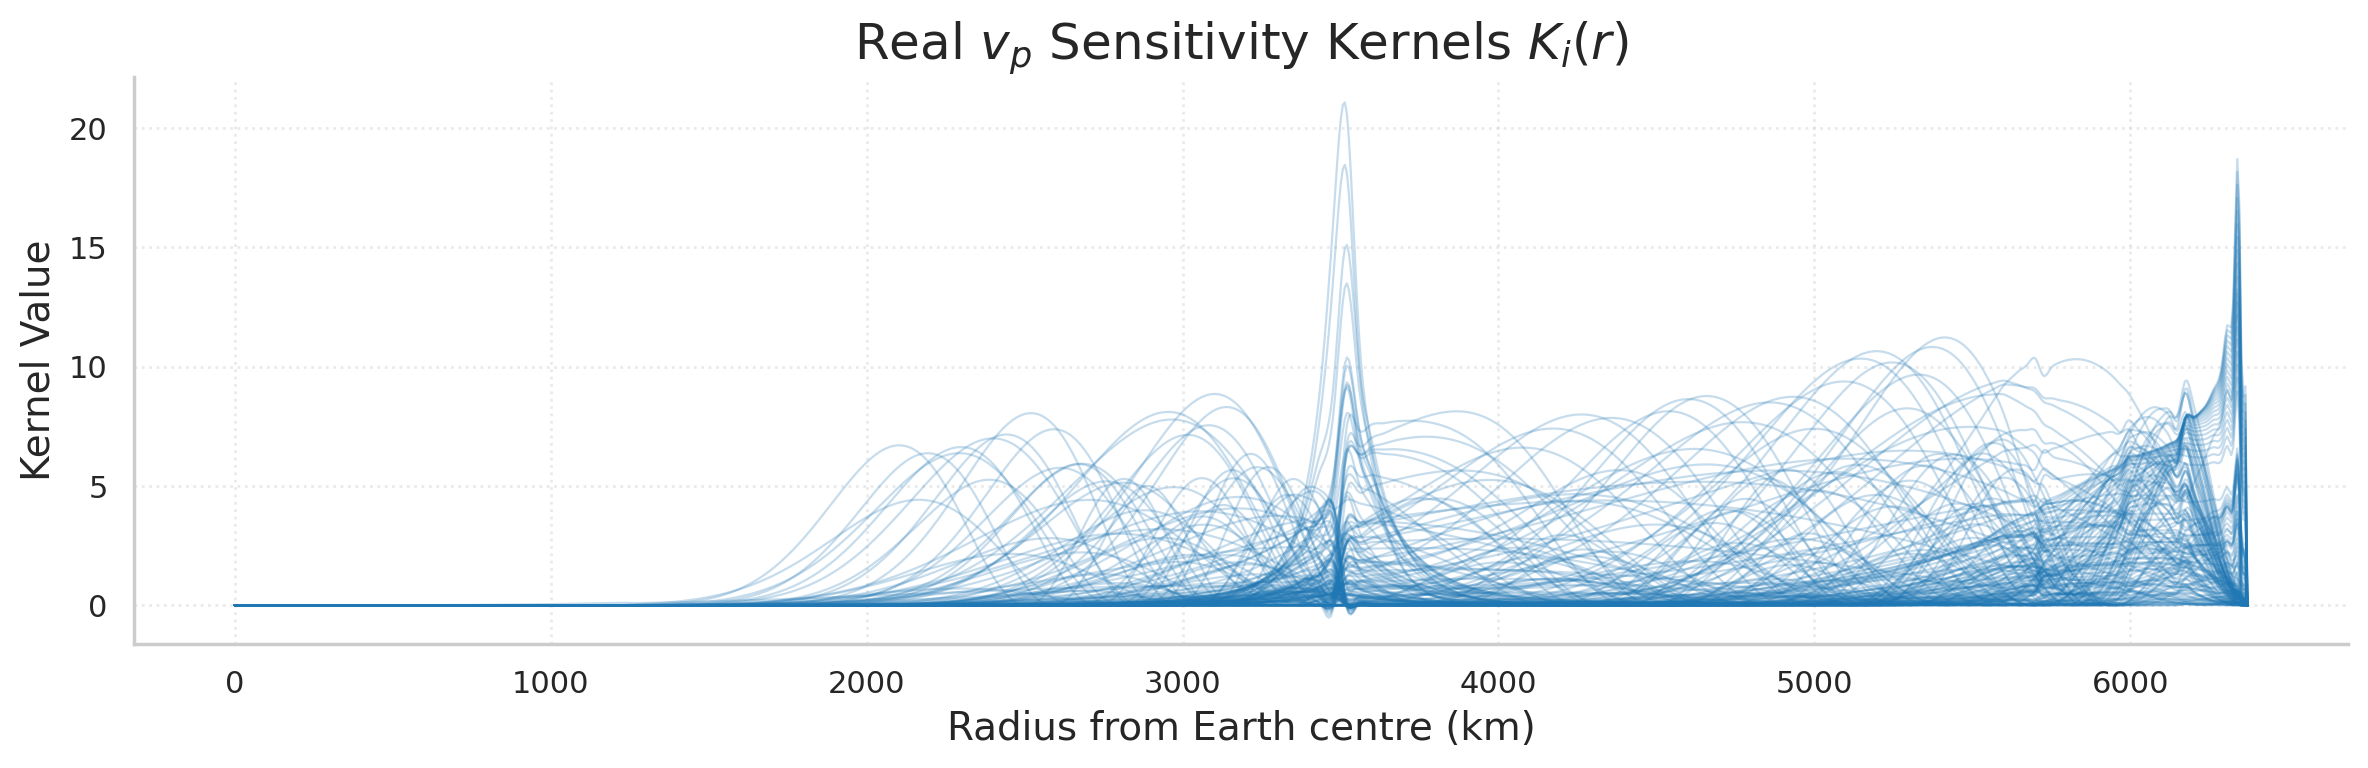

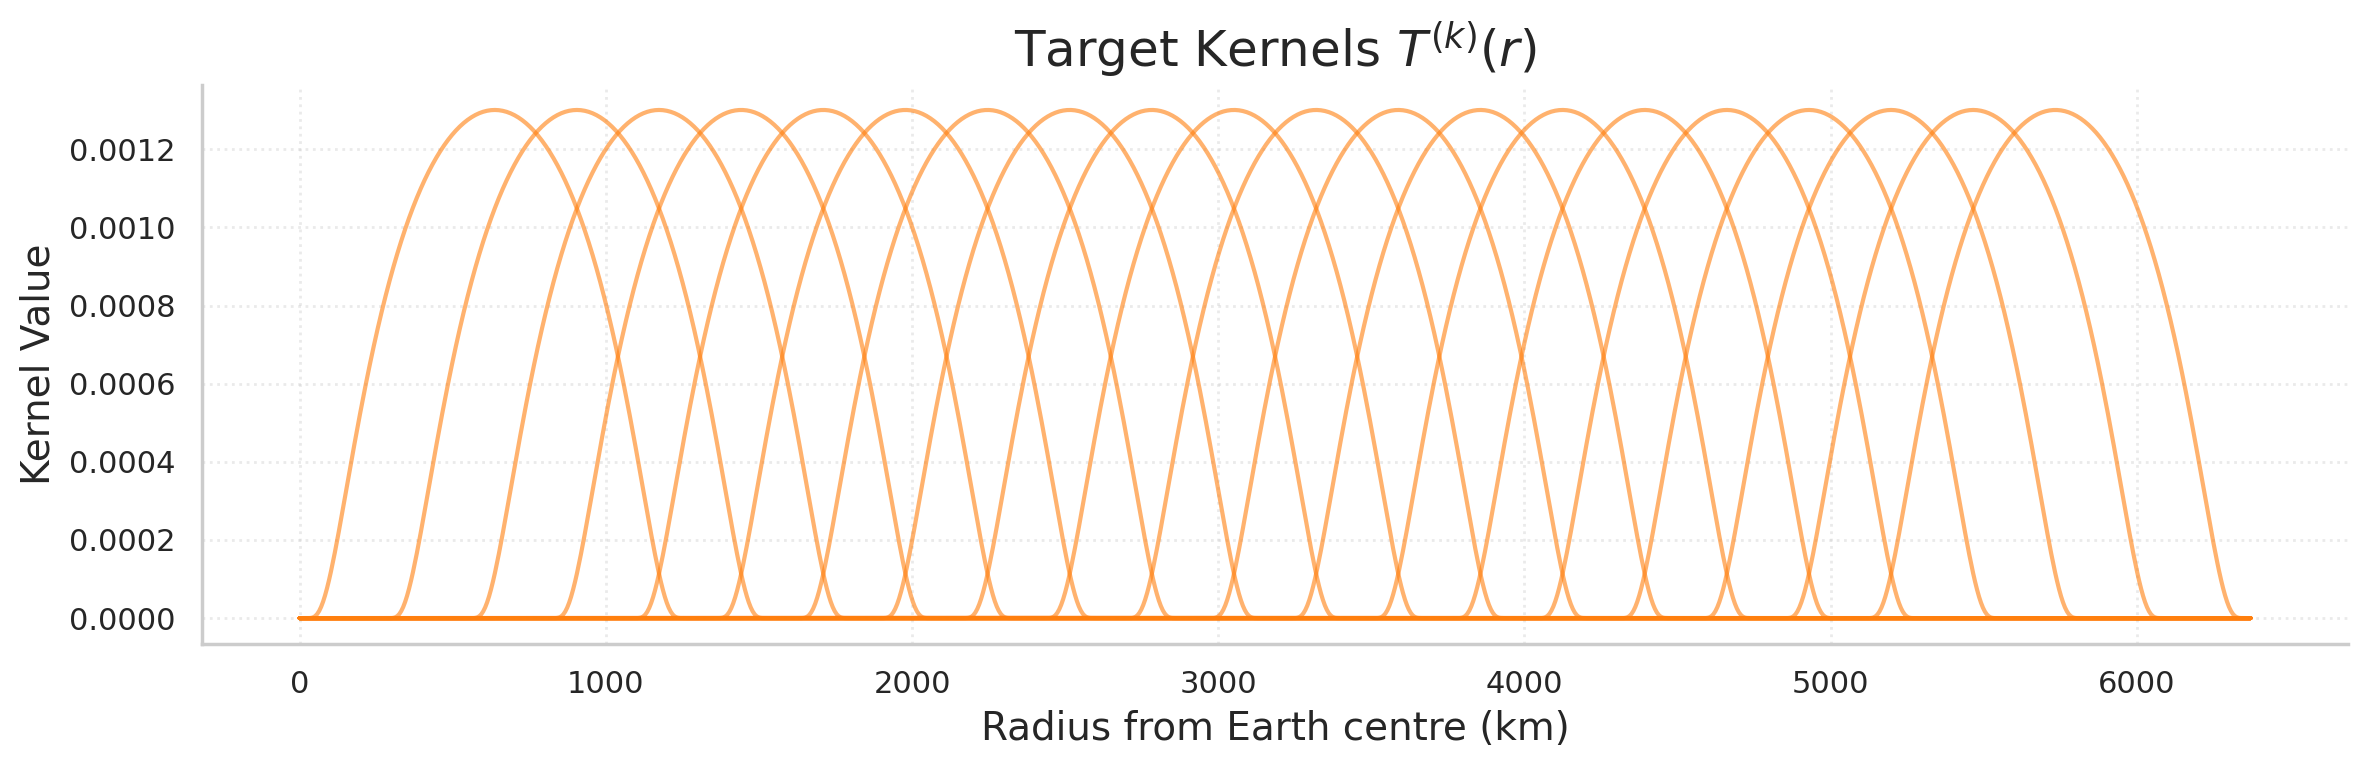

In [3]:
sns.set_theme(style='whitegrid', palette='muted', color_codes=True)

fig_title = 'Sensitivity Kernels (vp)'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_d):
    plt.plot(x, G.get_kernel(i).evaluate(x), color='tab:blue', alpha=0.25, linewidth=0.8)
plt.title(r'Real $v_p$ Sensitivity Kernels $K_i(r)$', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Kernel Value', fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

fig_title = 'Target Kernels'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
for i in range(N_p):
    plt.plot(x, T.get_kernel(i).evaluate(x), color='tab:orange', alpha=0.6, linewidth=1.5)
plt.title(r'Target Kernels $T^{(k)}(r)$', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Kernel Value', fontsize=14)
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Synthetic Model, Data Noise, and Reconstruction

We generate noisy observations from a smooth synthetic Earth model,
build the regularized SOLA operator, and compute the least-norm reconstruction.

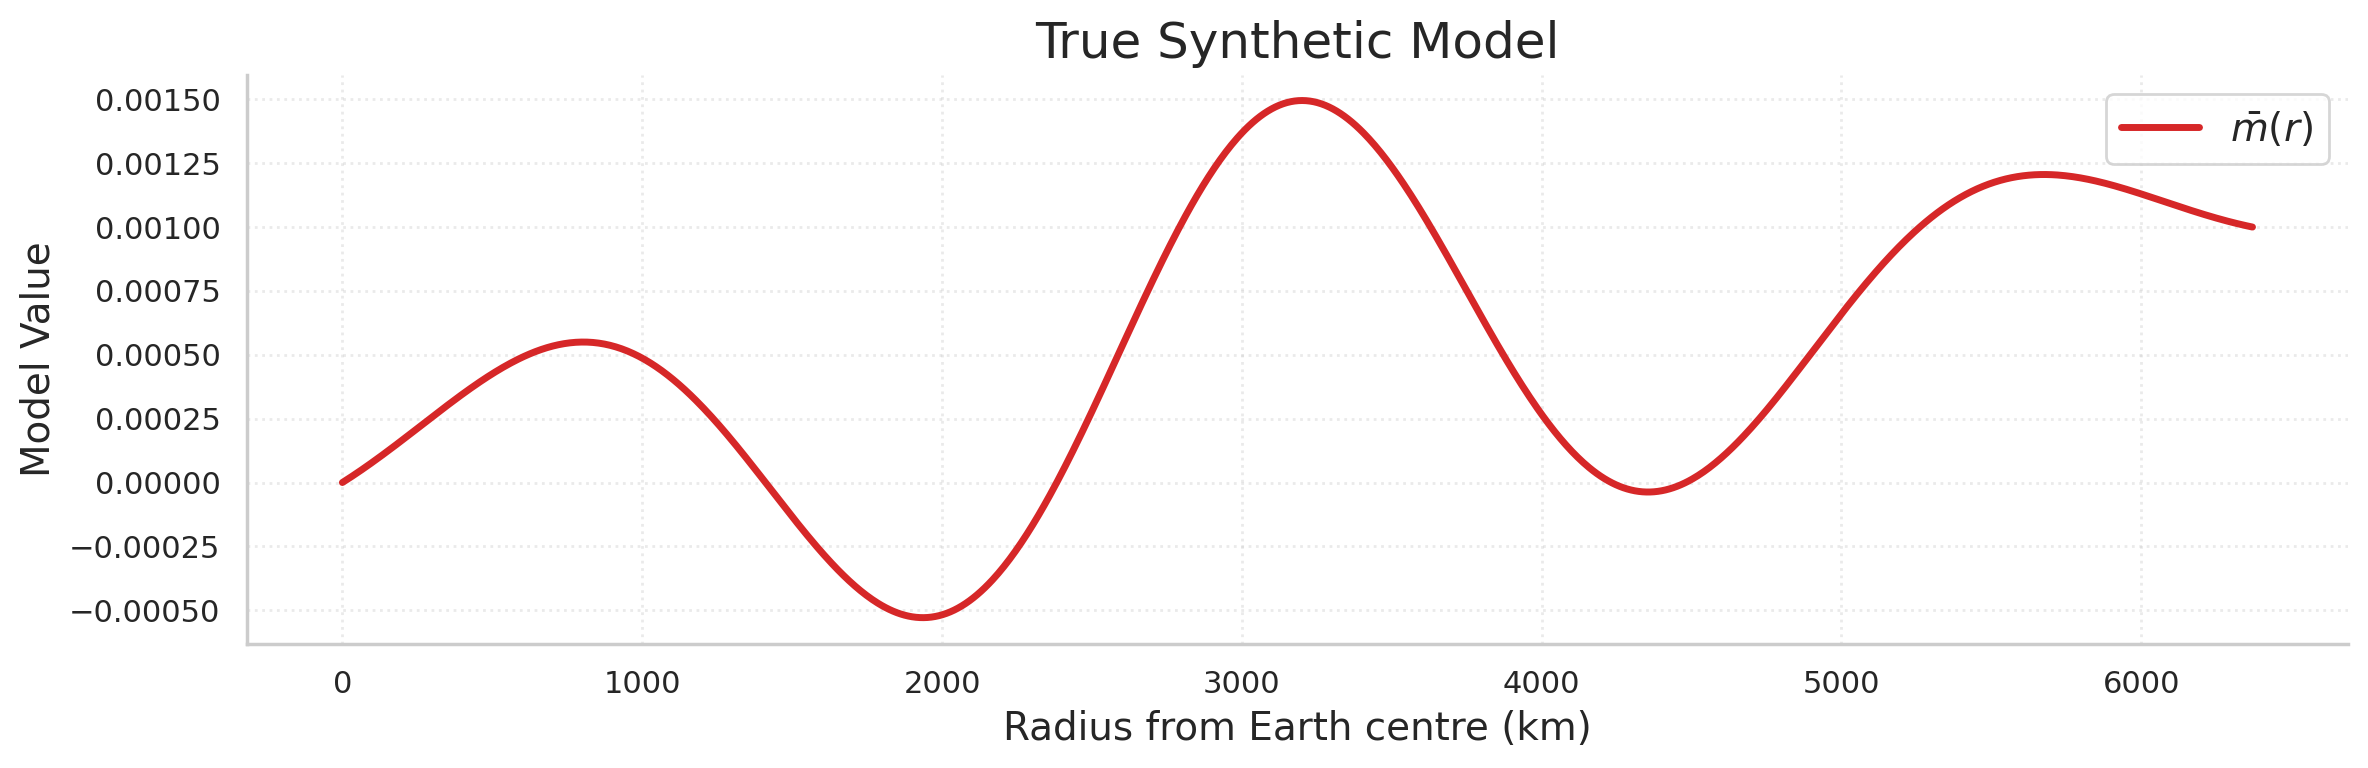

Signal-to-noise ratio: 10.0
Number of observations: 143
Data noise std: 0.996389
Computing SOLA operator ...


✓ SOLA operator construction complete!
Reconstruction L2 norm: 1.4242
Relative data misfit: 14.8 %


In [4]:
# Scale 1e-3: realistic vp perturbation (~0.1%),
# keeps data in [~1, ~10] so Lambda >> C_D with 10% noise.
m_bar = Function(
    M,
    evaluate_callable=lambda r: 1e-3 * (
        np.exp(-((r - 3000.0) / 2500.0) ** 2)
        * np.sin(5.0 * np.pi * r / EARTH_RADIUS_KM)
        + r / EARTH_RADIUS_KM
    ),
)

fig_title = 'True Model'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label=r'$\bar{m}(r)$')
plt.title('True Synthetic Model', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Model Value', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

d_bar = G(m_bar)
noise_level = 0.1 * np.max(np.abs(d_bar))
np.random.seed(42)
d_tilde = d_bar + np.random.normal(0, noise_level, d_bar.shape)

noise_variance = noise_level ** 2
C_D_matrix = noise_variance * np.eye(N_d)
gaussian_D_noise = GaussianMeasure.from_covariance_matrix(
    D, C_D_matrix, expectation=np.zeros(N_d)
)
gaussian_D = GaussianMeasure.from_covariance_matrix(
    D, C_D_matrix, expectation=d_tilde
)

print(f'Signal-to-noise ratio: {np.max(np.abs(d_bar)) / noise_level:.1f}')
print(f'Number of observations: {len(d_tilde)}')
print(f'Data noise std: {noise_level:.6f}')

print('Computing SOLA operator ...')
Lambda = G @ G.adjoint
cholesky_solver = CholeskySolver(galerkin=True, parallel=True, n_jobs=8)
W_inv = cholesky_solver(Lambda + gaussian_D.covariance)
G_inv = G.adjoint @ W_inv
X = T @ G_inv
print('✓ SOLA operator construction complete!')

m_tilde = G_inv(d_tilde)
print(f'Reconstruction L2 norm: {M.norm(m_tilde):.4f}')
print(f'Relative data misfit: {100 * D.norm(G(m_tilde) - d_tilde) / D.norm(d_tilde):.1f} %')

## Unimodular SOLA Property Inference

The corrected operator enforces $X_{\mathrm{uni}}(G(\mathbf{1})) = \mathbf{1}$:

$$
X_{\mathrm{uni}} = X - \frac{(X(v) - w)}{\beta}\, u^T,
\qquad
v = G(1),\; u = W^{-1}(v),\; \beta = \langle v, u \rangle,\; w = \mathbf{1}.
$$

Unimodularity before correction: [0.17015341 0.42494673 0.73097754 0.95080165 1.01407743]


Unimodularity after correction:  [1. 1. 1. 1. 1.]


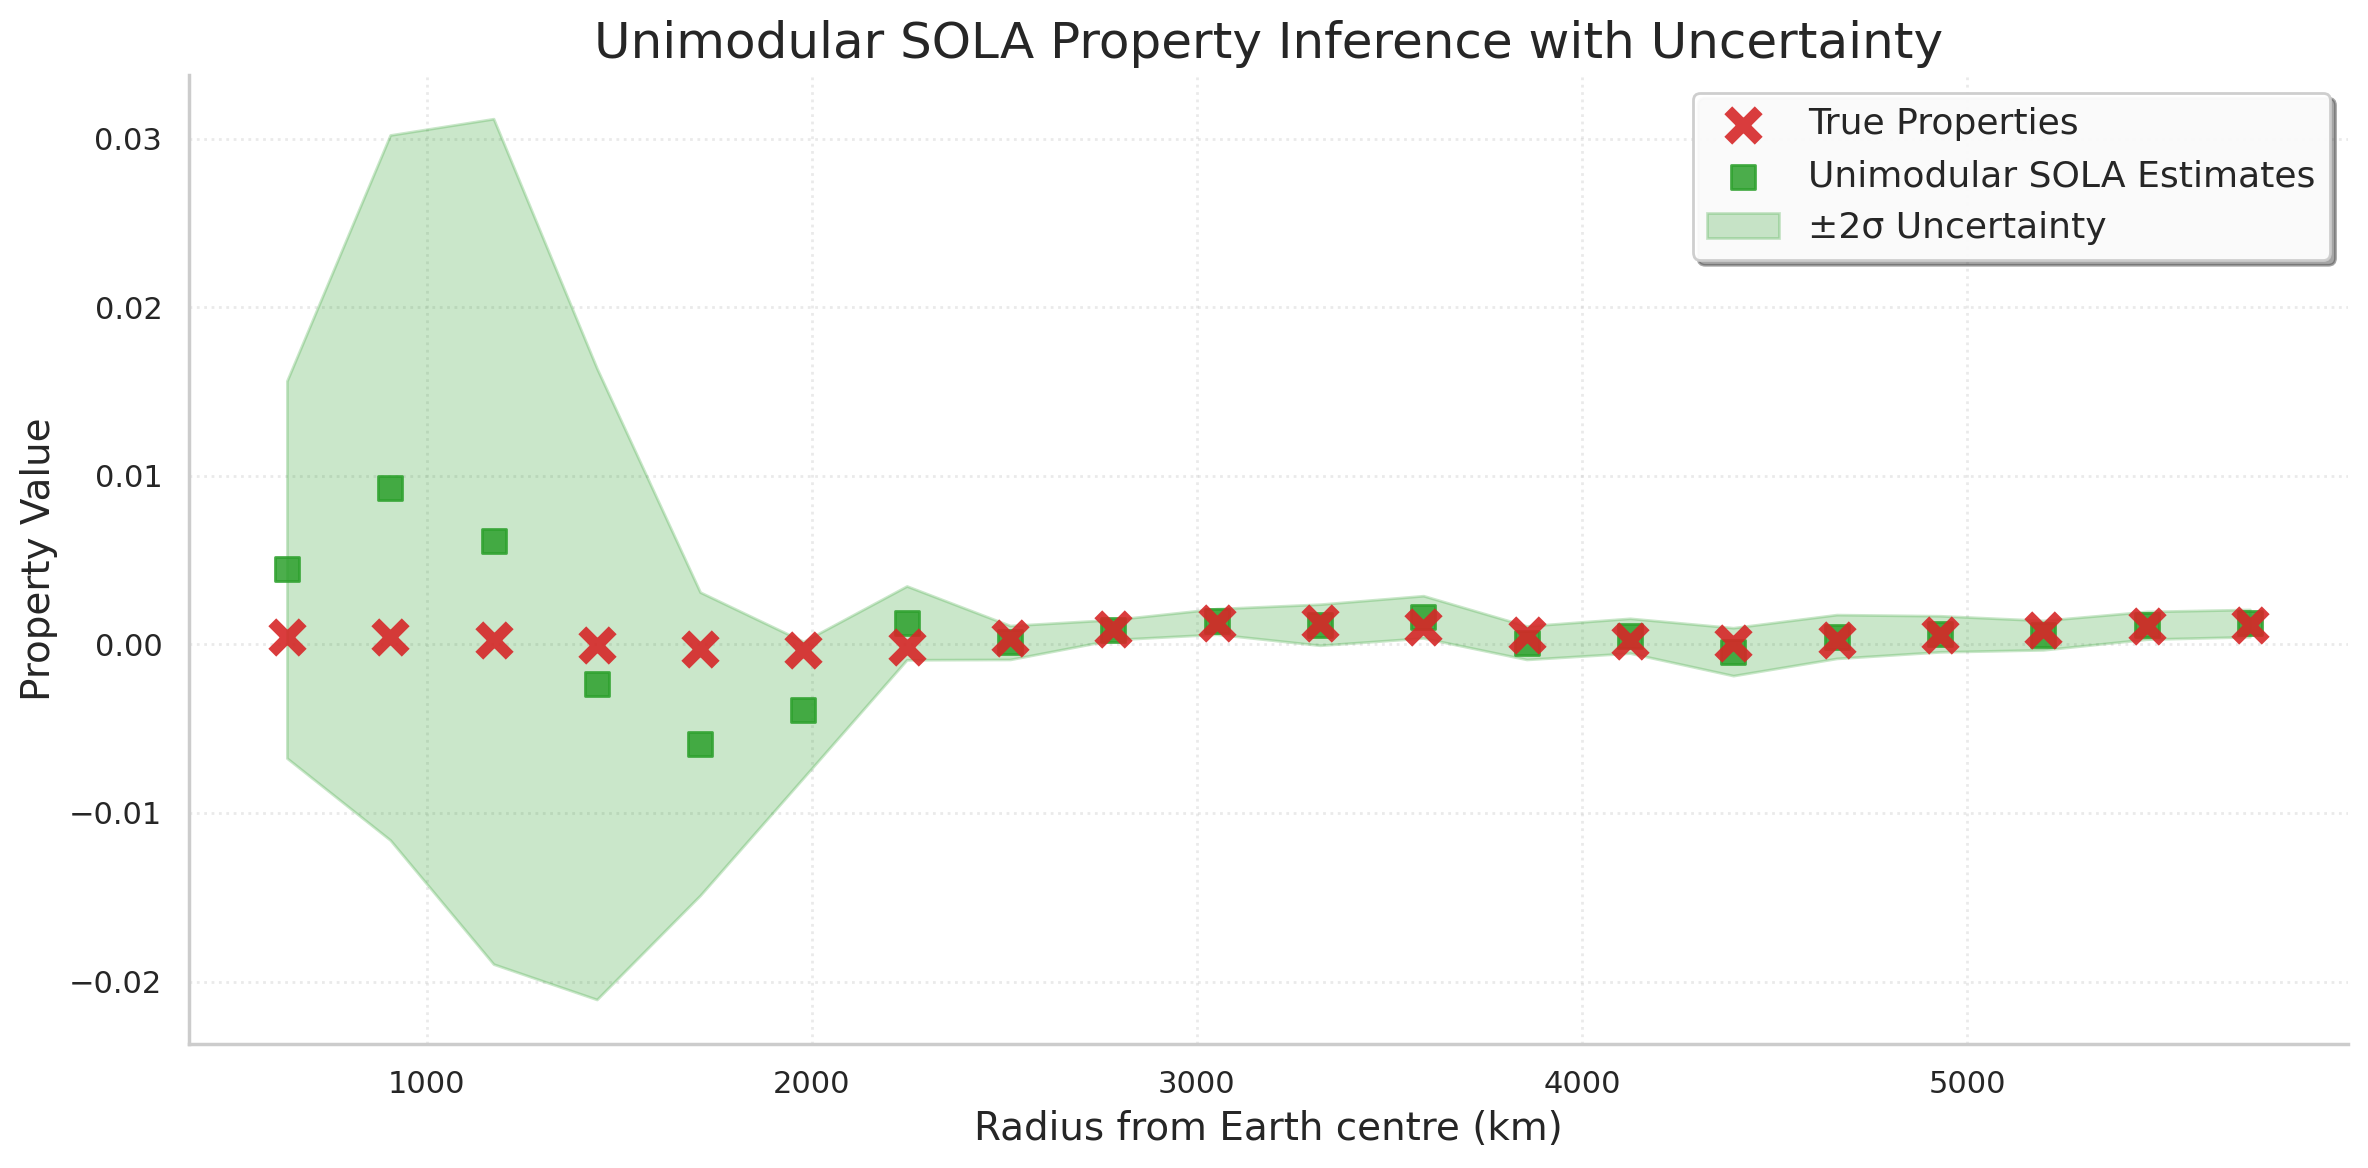

Properties within ±2σ: 20/20 (100.0%)
Mean absolute error:   0.0017
Average uncertainty (2σ): 0.0052


In [5]:
M_one = Function(M, evaluate_callable=lambda r: np.ones_like(r))
v = G(M_one)
w = np.ones(N_p)
u = W_inv(v)
beta = D.inner_product(v, u)
correction = LinearOperator.from_matrix(D, P, np.outer((X(v) - w) / beta, u))
X_unimodular = X - correction

print(f'Unimodularity before correction: {X(v)[:5]}')
print(f'Unimodularity after correction:  {X_unimodular(v)[:5]}')

property_measure_unimodular = gaussian_D.affine_mapping(operator=X_unimodular)
p_bar = T(m_bar)
p_mean = property_measure_unimodular.expectation
P_cov_mat = property_measure_unimodular.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std = np.sqrt(np.diag(P_cov_mat))

fig_title = 'Unimodular Property Inference Results'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 6), dpi=200)
plt.scatter(
    centers, p_bar, label='True Properties',
    color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10,
)
plt.scatter(
    centers, p_mean, label='Unimodular SOLA Estimates',
    color='tab:green', marker='s', s=80, alpha=0.85, zorder=5,
)
plt.fill_between(
    centers, p_mean - 2 * p_std, p_mean + 2 * p_std,
    alpha=0.25, color='tab:green', label='±2σ Uncertainty',
)
plt.title('Unimodular SOLA Property Inference with Uncertainty', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Property Value', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

property_errors = np.abs(p_mean - p_bar)
within_2sigma = np.sum(property_errors <= 2 * p_std)
print(f'Properties within ±2σ: {within_2sigma}/{len(p_bar)} ({100*within_2sigma/len(p_bar):.1f}%)')
print(f'Mean absolute error:   {np.mean(property_errors):.4f}')
print(f'Average uncertainty (2σ): {np.mean(2 * p_std):.4f}')

## Resolving Kernels

The resolving kernels of the unimodular operator $\mathcal{A}_{\mathrm{uni}} = X_{\mathrm{uni}} G$,
coloured by their relative misfit to the corresponding target kernels.

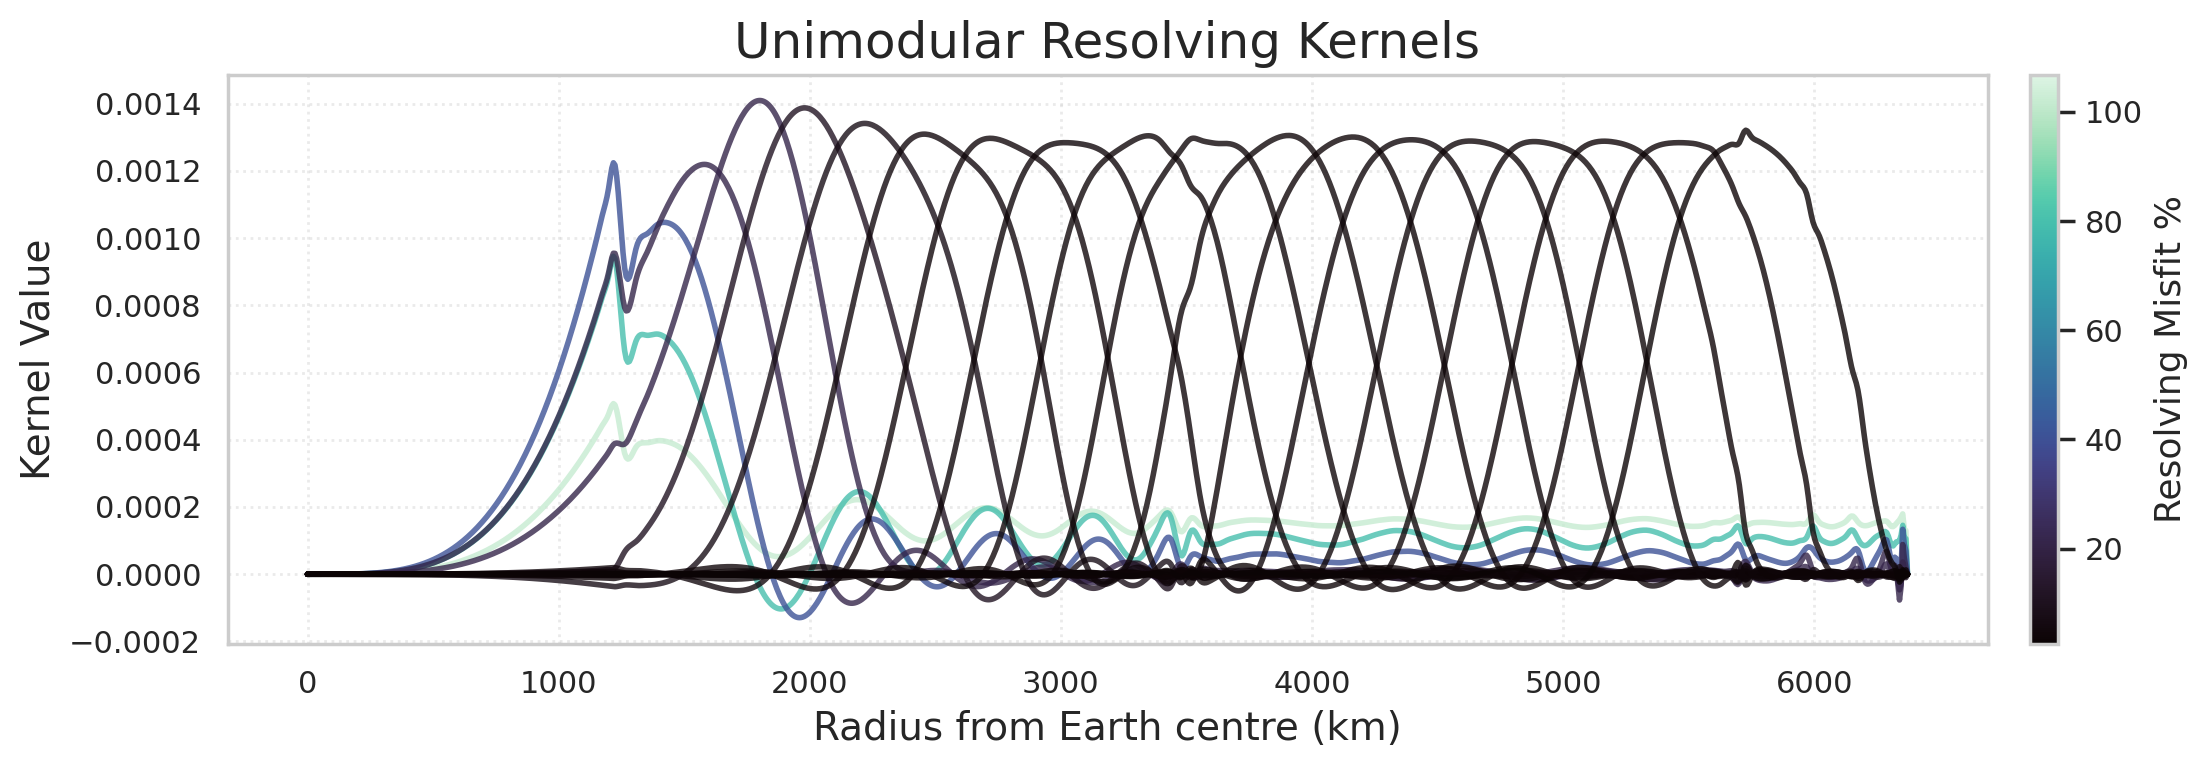

In [6]:
from matplotlib import cm

A_adjoint = (X_unimodular @ G).adjoint
cp = np.zeros(N_p)
resolving_misfits = np.zeros(N_p)

for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    target_kernel = T.get_kernel(i)
    resolving_misfits[i] = M.norm(A_i - target_kernel) / M.norm(target_kernel)
    cp[i] = 0

resolving_misfits_percent = 100 * resolving_misfits
vmin = resolving_misfits_percent.min() * 0.95
vmax = resolving_misfits_percent.max() * 1.05
norm = plt.Normalize(vmin, vmax)
cmap = plt.colormaps.get_cmap('mako')

fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
ax.set_title('Unimodular Resolving Kernels', fontsize=18)
ax.set_xlabel('Radius from Earth centre (km)', fontsize=14)
ax.set_ylabel('Kernel Value', fontsize=14)

for i in range(N_p):
    cp[i] = 1
    A_i = A_adjoint(cp)
    color = cmap(norm(resolving_misfits_percent[i]))
    ax.plot(x, A_i.evaluate(x), alpha=0.8, linewidth=2, color=color)
    cp[i] = 0

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Resolving Misfit %', fontsize=13)
ax.grid(True, linestyle=':', alpha=0.4)
fig.tight_layout()
fig.savefig(os.path.join(figures_folder, 'unimodular_resolving_kernels.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(figures_folder, 'unimodular_resolving_kernels.pdf'), bbox_inches='tight')
plt.show()

## 20-Cell Physical Boxcar Discretization

We discretize the model domain $[0, 6371]$ km into 20 equal cells of width
$\Delta r = 6371/20 \approx 318.6$ km each.
The discrete cell volumes (widths) form the `V` vector for `sola-base`.

Discrete model dimension: 20
G_disc matrix shape: (143, 20)
T_disc matrix shape: (20, 20)
Cell width: 318.55 km


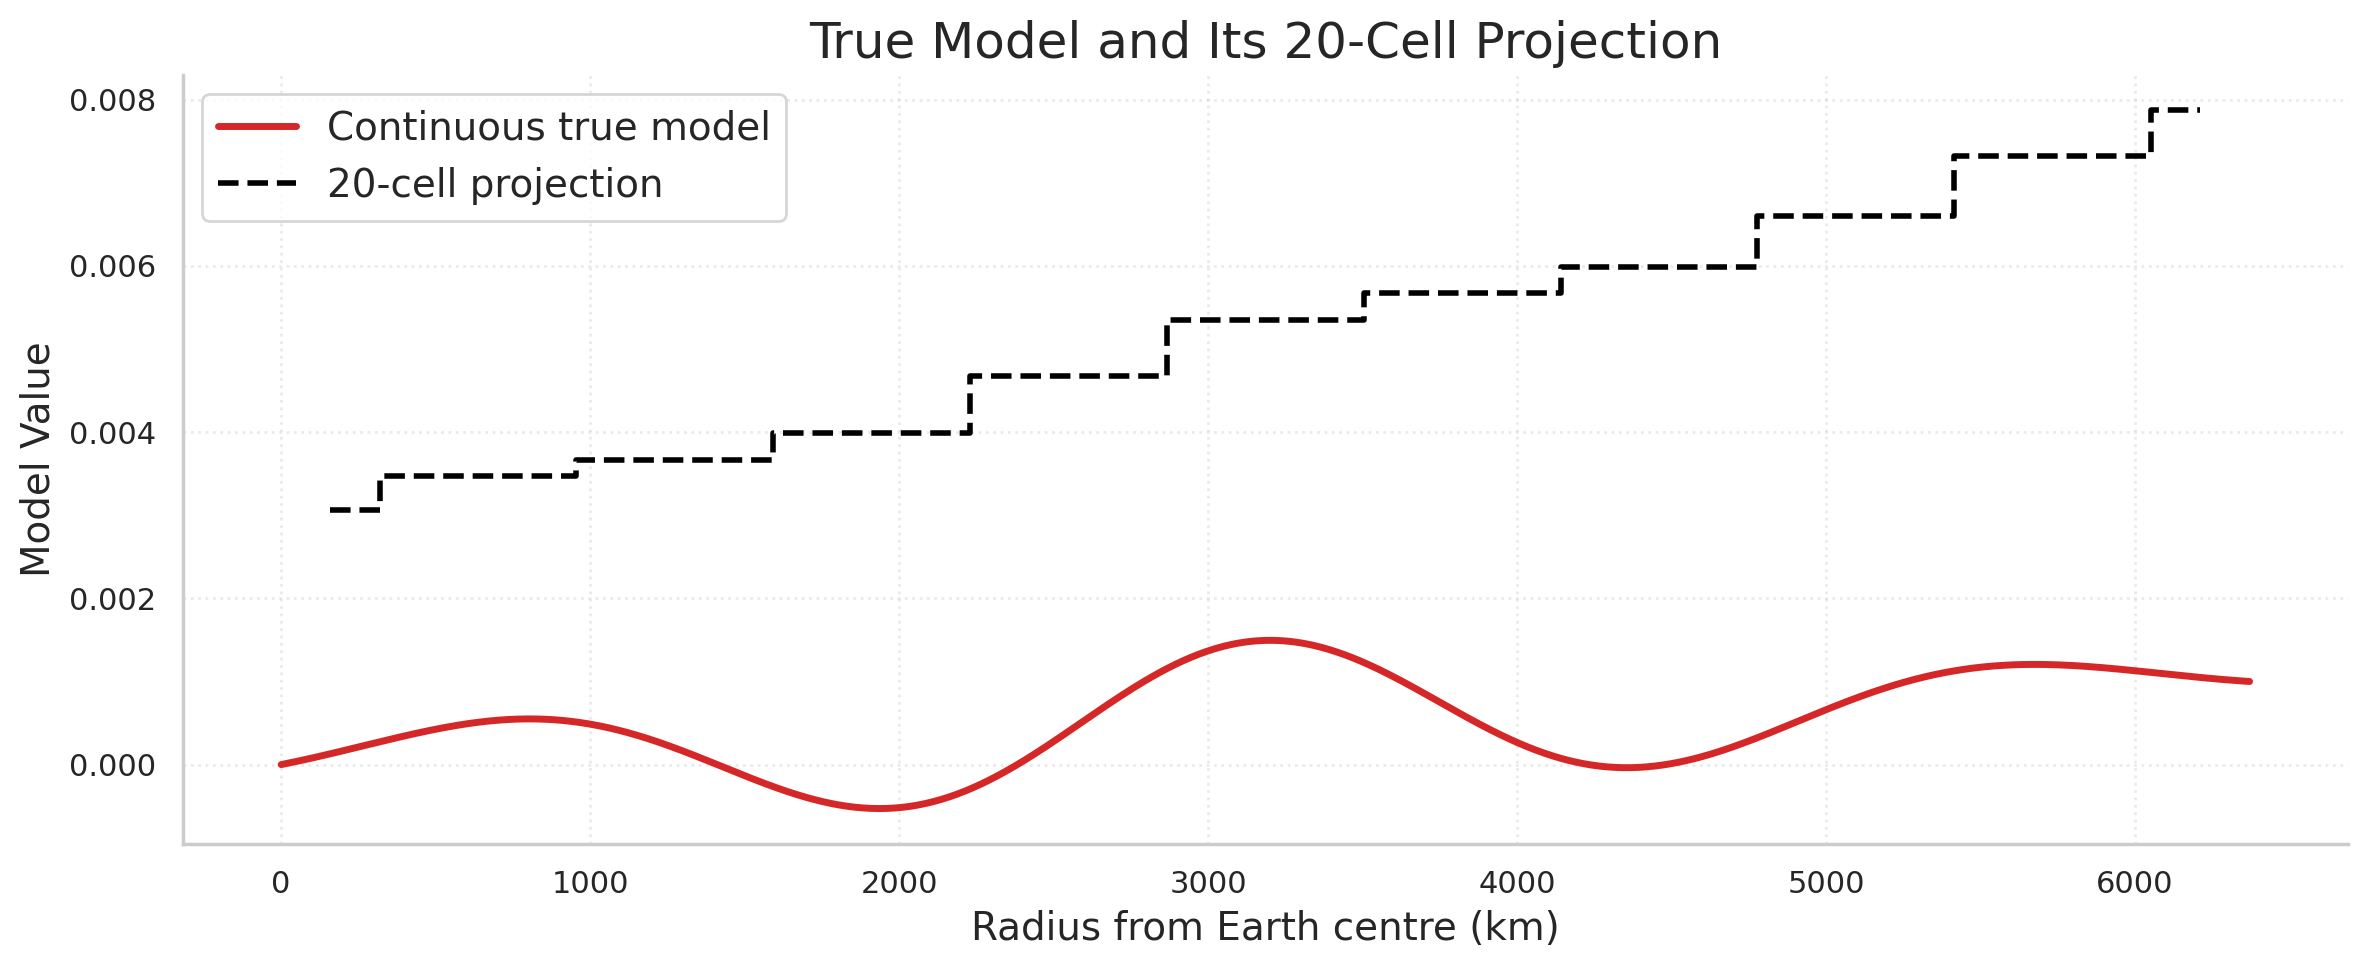

In [7]:
N_box = 20
box_edges  = np.linspace(function_domain.a, function_domain.b, N_box + 1)
box_centers = 0.5 * (box_edges[:-1] + box_edges[1:])
cell_widths = np.diff(box_edges)
box_width   = cell_widths[0]

M_disc_functions = Lebesgue(N_box, function_domain, basis='none')
boxcar_function_provider = BoxCarFunctionProvider(
    M_disc_functions,
    default_width=box_width,
    centers=box_centers,
    normalize=False,
    default_height=1.0,
)
M_disc_functions.set_basis_provider(
    CustomBasisProvider(
        M_disc_functions,
        boxcar_function_provider,
        orthonormal=False,
        basis_type='cell-boxcar',
    )
)

E_disc = EuclideanSpace(N_box)
mass_matrix          = np.diag(cell_widths)
mass_operator        = LinearOperator.self_adjoint_from_matrix(E_disc, mass_matrix)
inverse_mass_operator = LinearOperator.self_adjoint_from_matrix(
    E_disc, np.diag(1.0 / cell_widths)
)
M_disc = MassWeightedHilbertSpace(E_disc, mass_operator, inverse_mass_operator)

G_cell = SOLAOperator(
    M_disc_functions, D,
    kernels=[G.get_kernel(i) for i in range(N_d)],
    integration_config=G.integration,
)
T_cell = SOLAOperator(
    M_disc_functions, P,
    kernels=[T.get_kernel(k) for k in range(N_p)],
    integration_config=T.integration,
)

G_disc_mat = G_cell.matrix(dense=True, parallel=True, n_jobs=8)
T_disc_mat = T_cell.matrix(dense=True, parallel=True, n_jobs=8)

G_disc_base = LinearOperator.from_matrix(E_disc, D, G_disc_mat)
T_disc_base = LinearOperator.from_matrix(E_disc, P, T_disc_mat)
G_disc = LinearOperator.from_formal_adjoint(M_disc, D, G_disc_base)
T_disc = LinearOperator.from_formal_adjoint(M_disc, P, T_disc_base)

m_bar_disc_coeffs = M_disc_functions.to_components(m_bar)
m_bar_disc        = M_disc_functions.from_components(m_bar_disc_coeffs)
m_bar_disc_levels = m_bar_disc.evaluate(box_centers)

print(f'Discrete model dimension: {N_box}')
print(f'G_disc matrix shape: {G_disc_mat.shape}')
print(f'T_disc matrix shape: {T_disc_mat.shape}')
print(f'Cell width: {box_width:.2f} km')

fig_title = 'True Model Continuous vs Discretized'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 5), dpi=200)
plt.plot(x, m_bar.evaluate(x), color='tab:red', linewidth=2.5, label='Continuous true model')
plt.step(
    box_centers, m_bar_disc_levels, where='mid',
    color='black', linewidth=2.0, linestyle='--', label='20-cell projection',
)
plt.title('True Model and Its 20-Cell Projection', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Model Value', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

Discrete unimodularity check: [1. 1. 1. 1. 1.]
Max |continuous − discrete|:  1.3271e-02


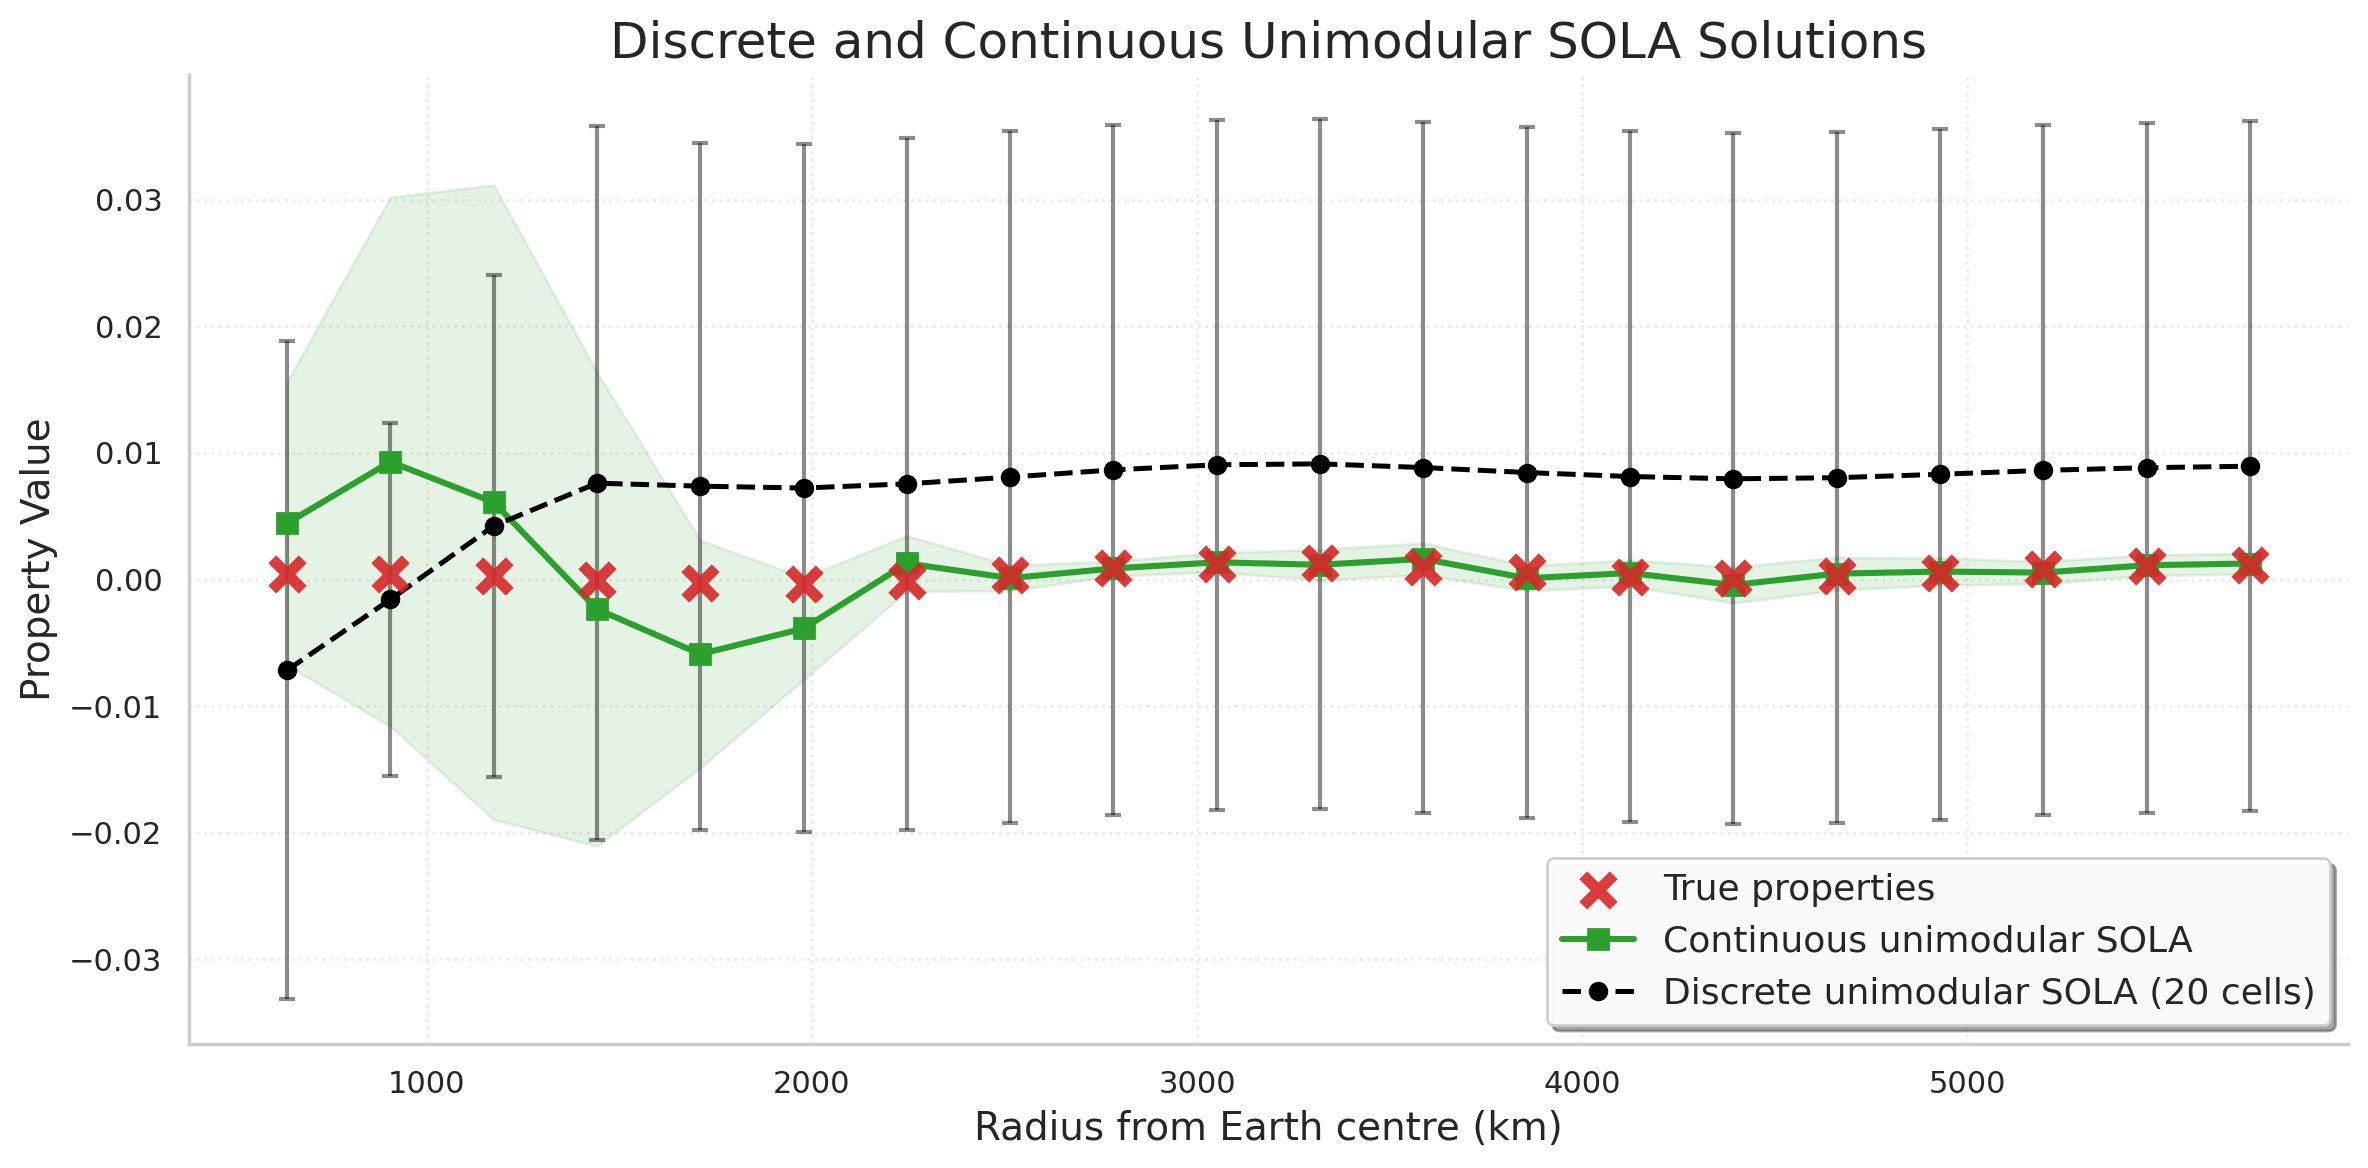

In [8]:
Lambda_disc = G_disc @ G_disc.adjoint
W_disc = cholesky_solver(Lambda_disc + gaussian_D.covariance)
G_disc_inv = G_disc.adjoint @ W_disc
X_disc = T_disc @ G_disc_inv

m_one_disc = M_disc_functions.to_components(M_one)
v_disc = G_disc(m_one_disc)
u_disc = W_disc(v_disc)
beta_disc = D.inner_product(v_disc, u_disc)
w_disc = np.ones(N_p)
correction_disc = LinearOperator.from_matrix(
    D, P,
    np.outer((X_disc(v_disc) - w_disc) / beta_disc, u_disc),
)
X_disc_unimodular = X_disc - correction_disc

property_measure_disc_unimodular = gaussian_D.affine_mapping(operator=X_disc_unimodular)
p_mean_disc = property_measure_disc_unimodular.expectation
P_cov_disc  = property_measure_disc_unimodular.covariance.matrix(dense=True, parallel=True, n_jobs=8)
p_std_disc  = np.sqrt(np.diag(P_cov_disc))

print(f'Discrete unimodularity check: {X_disc_unimodular(v_disc)[:5]}')
print(f'Max |continuous − discrete|:  {np.max(np.abs(p_mean - p_mean_disc)):.4e}')

fig_title = 'Discrete vs Continuous Unimodular SOLA Properties'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')
plt.figure(figsize=(12, 6), dpi=200)
plt.scatter(centers, p_bar, label='True properties',
            color='tab:red', marker='x', s=120, alpha=0.9, linewidths=4, zorder=10)
plt.plot(centers, p_mean,
         color='tab:green', marker='s', linewidth=2.2, markersize=7,
         label='Continuous unimodular SOLA', zorder=6)
plt.plot(centers, p_mean_disc,
         color='black', marker='o', linestyle='--', linewidth=1.8, markersize=6,
         label='Discrete unimodular SOLA (20 cells)', zorder=7)
plt.fill_between(centers, p_mean - 2*p_std, p_mean + 2*p_std,
                 alpha=0.12, color='tab:green', zorder=1)
plt.errorbar(centers, p_mean_disc, yerr=2*p_std_disc, fmt='none',
             ecolor='black', alpha=0.45, capsize=3, capthick=1.5, zorder=5)
plt.title('Discrete and Continuous Unimodular SOLA Solutions', fontsize=18)
plt.xlabel('Radius from Earth centre (km)', fontsize=14)
plt.ylabel('Property Value', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(fontsize=13, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
sns.despine()
plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

## Export to sola-base and Compare Outputs

We export the discretized problem in `sola-base` file format, run the full
`sola-base` pipeline (preproc → lsqr → postproc → ak), then read back the
results and compare them to the notebook's discrete solution.

In [9]:
import shutil
import subprocess
import sys as _sys

workspace_root  = Path('/home/adrian/PhD/Inferences')
sola_base_dir   = workspace_root.parent / 'sola-base'
sola_input_dir  = sola_base_dir / 'sola_inputs_earth_demo'
sola_output_dir = sola_base_dir / 'sola_outputs_earth_demo'
targets_dir     = sola_input_dir / 'T'

for path in (sola_input_dir, sola_output_dir):
    if path.exists():
        shutil.rmtree(path)
targets_dir.mkdir(parents=True, exist_ok=True)
(sola_output_dir / 'A').mkdir(parents=True, exist_ok=True)

def write_dense_vector(path, values):
    np.savetxt(path, np.asarray(values, dtype=float))

def write_sparse_matrix_ijv(path, matrix, tol=1e-14):
    matrix = np.asarray(matrix, dtype=float)
    rows, cols = np.where(np.abs(matrix) > tol)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(f'{len(rows)}\n')
        handle.write(f'{matrix.shape[0]} {matrix.shape[1]}\n')
        for i, j in zip(rows, cols):
            handle.write(f'{i} {j} {matrix[i, j]:.16e}\n')

def write_sparse_vector_jv(path, vector, tol=1e-14):
    vector = np.asarray(vector, dtype=float)
    nz = np.where(np.abs(vector) > tol)[0]
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(f'{len(vector)}\n')
        for j in nz:
            handle.write(f'{j} {vector[j]:.16e}\n')

V_sola     = cell_widths.copy()          # km — cell volumes for sola-base
dstd_sola  = np.sqrt(np.diag(C_D_matrix))
T_sola     = T_disc_mat / V_sola[None, :]
ks_to_solve = np.arange(N_p, dtype=int)
eta_sola   = 1.0
eta_str    = str(eta_sola).replace('.', 'p')

write_sparse_matrix_ijv(sola_input_dir / 'G', G_disc_mat)
write_dense_vector(sola_input_dir / 'd', d_tilde)
write_dense_vector(sola_input_dir / 'dstd', dstd_sola)
write_dense_vector(sola_input_dir / 'V', V_sola)

for k in ks_to_solve:
    write_sparse_vector_jv(targets_dir / f'T_{k}', T_sola[k])

np.savetxt(sola_input_dir / 'ks_to_solve', ks_to_solve, fmt='%d')

parameters_cfg = '\n'.join([
    '[inversion]',
    f'eta = {eta_sola}',
    'iters = 500',
    'dumpiter = 100',
    '',
    '[folders]',
    f'input = {sola_input_dir.name}',
    f'output = {sola_output_dir.name}',
]) + '\n'
(sola_base_dir / 'parameters.cfg').write_text(parameters_cfg, encoding='utf-8')

compile_result = subprocess.run(
    ['bash', 'compile.sh'],
    cwd=sola_base_dir / 'LSQR_SOLA_paral',
    check=True, capture_output=True, text=True,
)
if compile_result.stdout.strip(): print(compile_result.stdout)
if compile_result.stderr.strip(): print(compile_result.stderr)

env = os.environ.copy()
env.setdefault('OMP_NUM_THREADS', '4')
ks_rel_path = f'{sola_input_dir.name}/ks_to_solve'
for command in (
    [_sys.executable, 'sola_preproc.py'],
    [_sys.executable, 'sola_lsqr.py', ks_rel_path],
    [_sys.executable, 'sola_postproc.py'],
    [_sys.executable, 'sola_ak.py', ks_rel_path],
):
    result = subprocess.run(
        command, cwd=sola_base_dir,
        check=True, capture_output=True, text=True, env=env,
    )
    print(' '.join(command))
    if result.stdout.strip(): print(result.stdout)
    if result.stderr.strip(): print(result.stderr)

print(f'Exported sola-base inputs to: {sola_input_dir}')
print(f'sola-base outputs written to: {sola_output_dir}')
print(f'eta used for sola-base run:   {eta_sola:.6f}')

/home/adrian/miniconda3/envs/inferences3/bin/python3.11 sola_preproc.py
/home/adrian/PhD/sola-base/sola_preproc.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  G = pd.read_table( os.path.join(input_folder, 'G'), delim_whitespace=True, skiprows=2, header=None, names=['i','j','val'])

/home/adrian/miniconda3/envs/inferences3/bin/python3.11 sola_lsqr.py sola_inputs_earth_demo/ks_to_solve
reading sparse matrix from 'sola_inputs_earth_demo/Q_sparse0_norm_1p0' ... 
(21x142)-(2753) 
Reorganisation liste des colonnes

Fin lecture matricesparse stats (0x55e6f34886b0):
	size: 21x142, nb items: 2753
	density: 92.320587
free sparse matrix (0x55e6f34886b0)
./LSQR_SOLA_paral/LSQR_inversion_for_SOLA_N_paral sola_inputs_earth_demo/Q_sparse0_norm_1p0 sola_inputs_earth_demo/T/T sola_inputs_earth_demo/ks_to_solve sola_outputs_earth_demo/SOLUTION_1p0/SOLUTION 500 1.000000 sola_inputs_earth_demo/c_spars

/home/adrian/miniconda3/envs/inferences3/bin/python3.11 sola_ak.py sola_inputs_earth_demo/ks_to_solve
/home/adrian/PhD/sola-base/sola_ak.py:44: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  G = pd.read_table(

Exported sola-base inputs to: /home/adrian/PhD/sola-base/sola_inputs_earth_demo
sola-base outputs written to: /home/adrian/PhD/sola-base/sola_outputs_earth_demo
eta used for sola-base run:   1.000000


SOLA-BASE VS NOTEBOOK COMPARISON
Max |property mean difference|:   2.1980e-08
Max |property std difference|:    3.8618e-09
Mean notebook 2σ width:           2.6218e-02
Mean sola-base 2σ width:          2.6218e-02
Max |weight difference|:          4.7002e-09
Max |averaging-kernel difference|:3.9538e-05


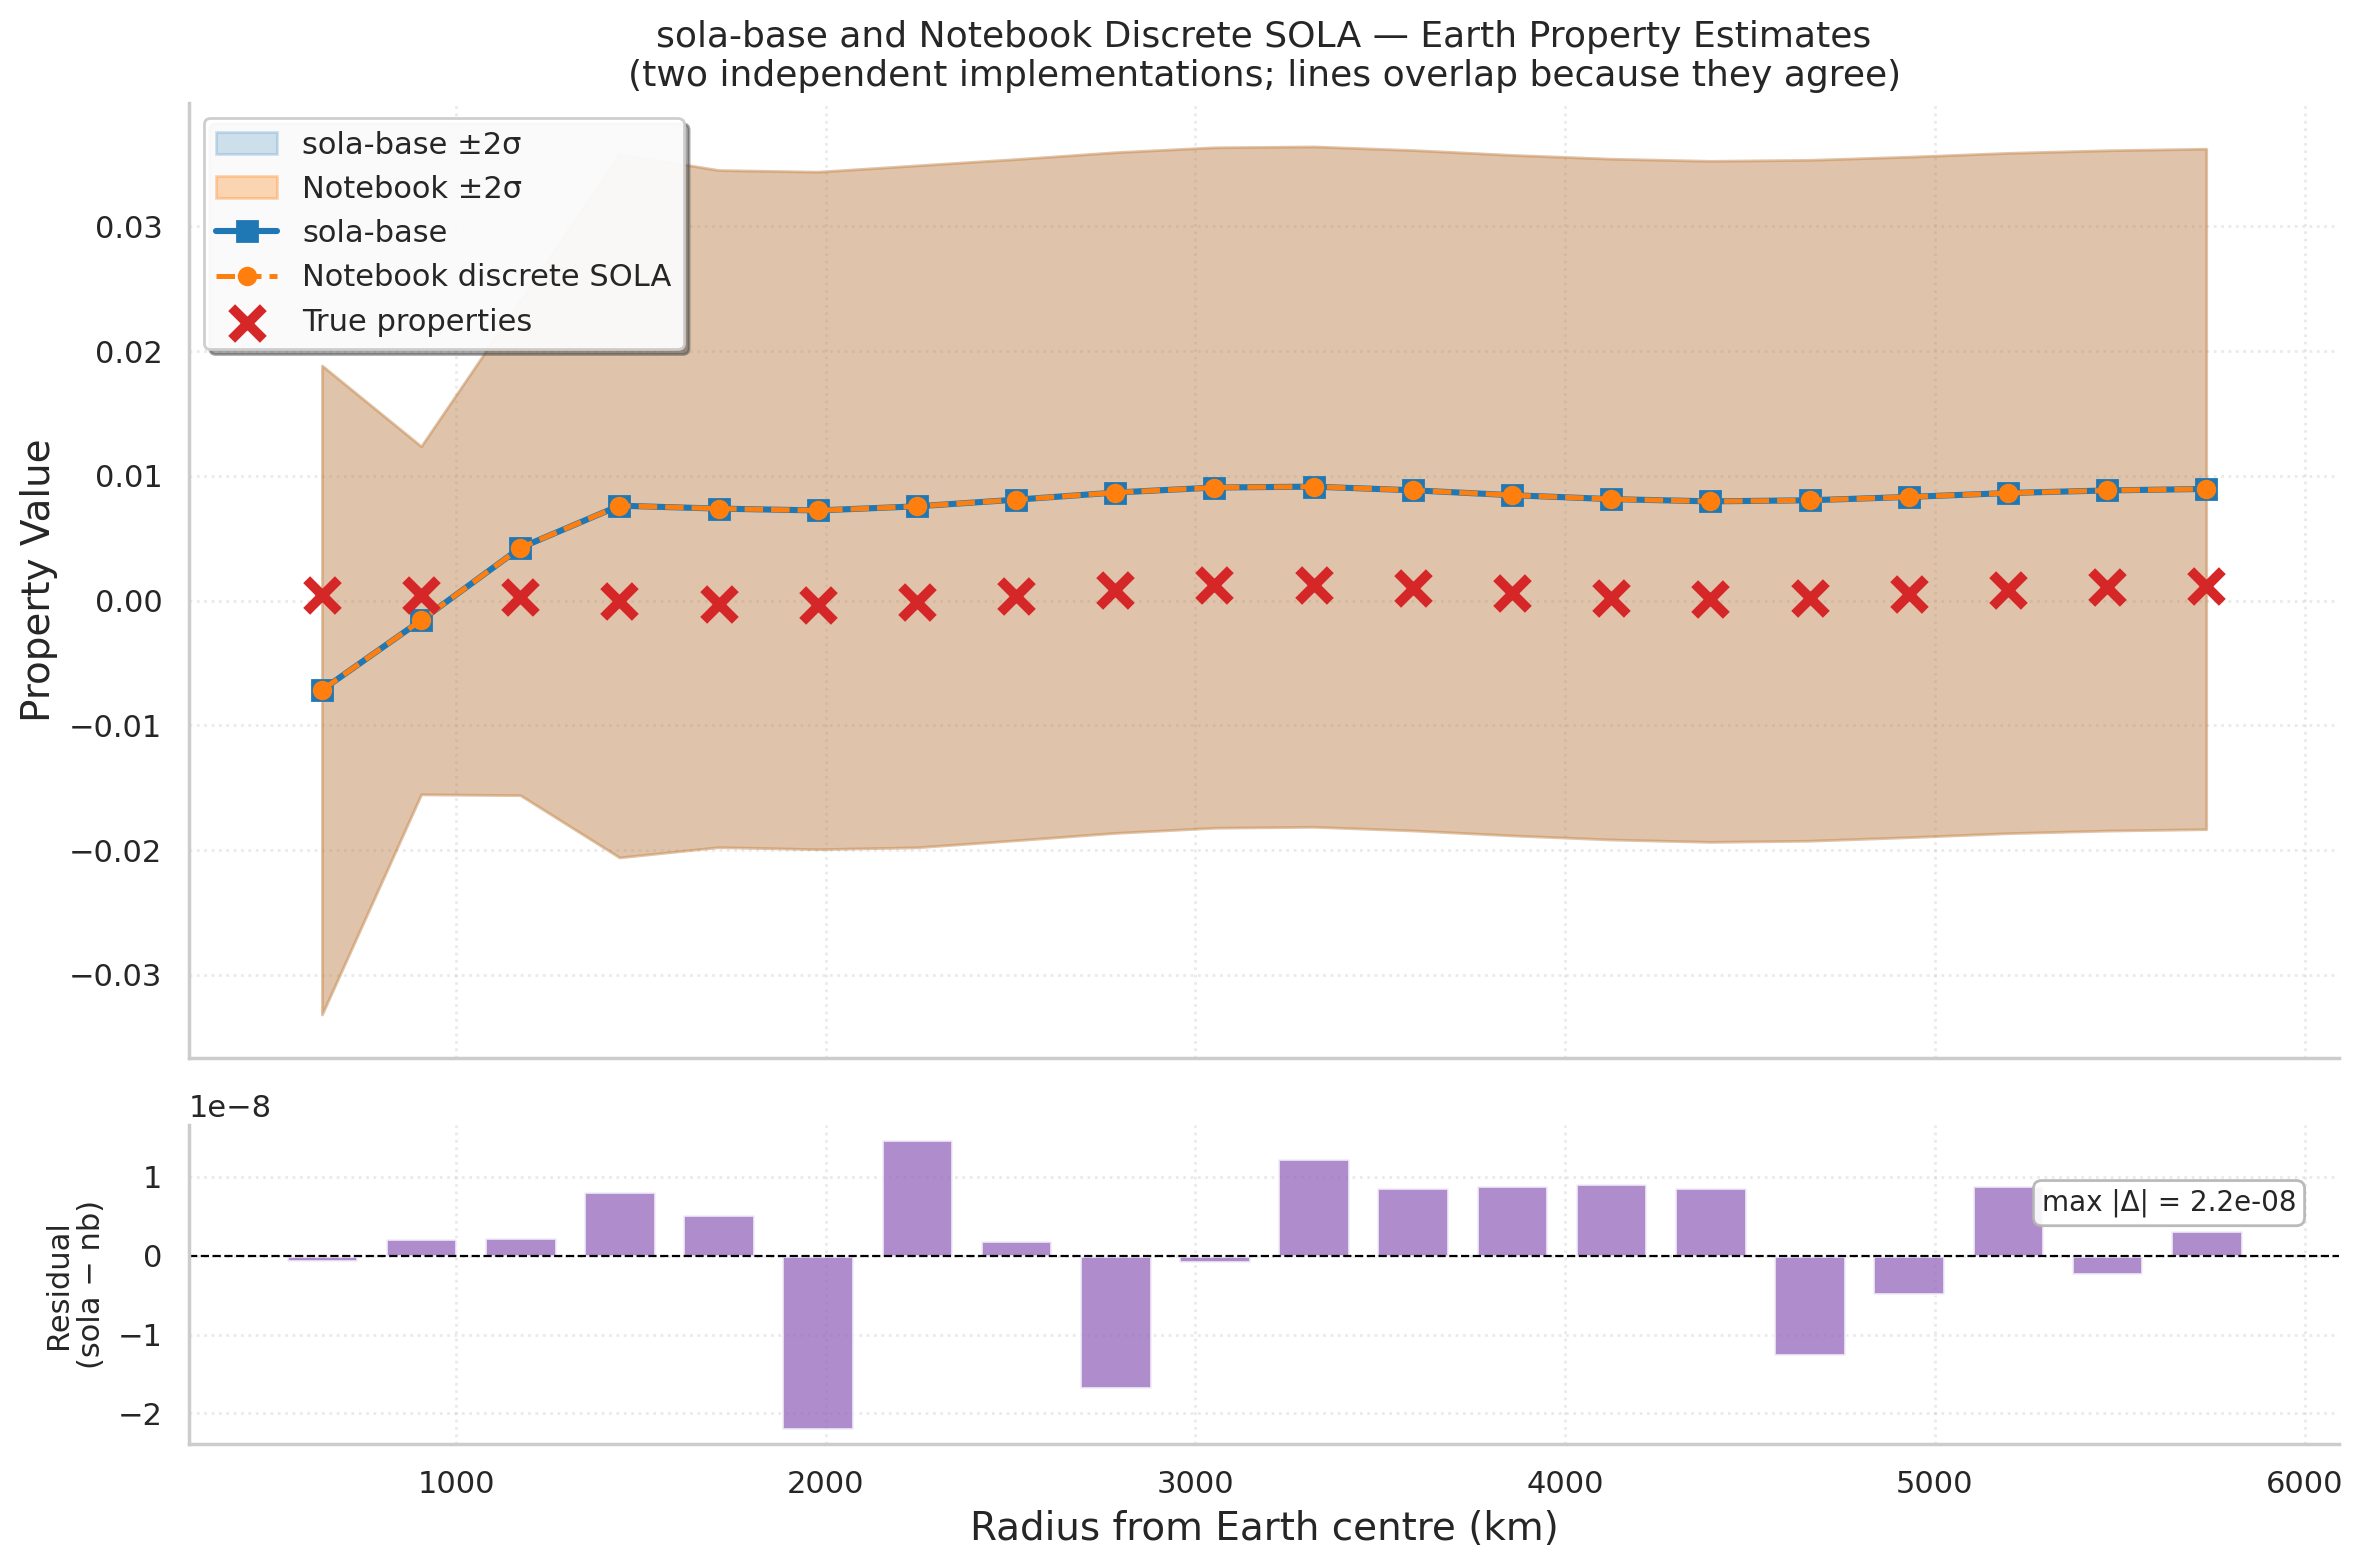

sola-base comparisons passed within the documented discrete round-trip tolerances.


In [10]:
sola_m = np.loadtxt(sola_output_dir / f'm_{eta_str}')
sola_mstd = np.loadtxt(sola_output_dir / f'mstd_{eta_str}')
sola_weights = np.vstack([
    np.loadtxt(sola_output_dir / f'SOLUTION_{eta_str}' / f'SOLUTION_{k}.txt')
    for k in ks_to_solve
])
sola_averaging_kernels = np.vstack([
    np.loadtxt(sola_output_dir / 'A' / f'A_{k}')
    for k in ks_to_solve
])

dstd_sola = np.loadtxt(sola_input_dir / 'dstd')
V_sola    = np.loadtxt(sola_input_dir / 'V')
G_sparse  = np.loadtxt(sola_input_dir / 'G_sparse0_norm', skiprows=2)
G_sparse_mat = np.zeros_like(G_disc_mat)
for i, j, value in G_sparse:
    G_sparse_mat[int(i), int(j)] = value

G_norm_expected = G_disc_mat / dstd_sola[:, None]
swap = []
for i in range(G_sparse_mat.shape[0]):
    diffs = np.max(np.abs(G_norm_expected - G_sparse_mat[i]), axis=1)
    swap.append(int(np.argmin(diffs)))
swap = np.asarray(swap)

X_disc_matrix      = X_disc_unimodular.matrix(dense=True, parallel=True, n_jobs=8)
X_disc_swapped_norm = X_disc_matrix[:, swap] * dstd_sola[swap][None, :]
A_disc_from_sola_coords = X_disc_swapped_norm @ G_sparse_mat / V_sola[None, :]
A_disc_integrated        = A_disc_from_sola_coords * V_sola[None, :]
sola_averaging_integrated = sola_averaging_kernels * V_sola[None, :]

property_diff       = sola_m - p_mean_disc
uncertainty_diff    = sola_mstd - p_std_disc
weight_diff         = sola_weights - X_disc_swapped_norm
averaging_diff      = sola_averaging_integrated - A_disc_integrated

print('SOLA-BASE VS NOTEBOOK COMPARISON')
print('=' * 50)
print(f'Max |property mean difference|:   {np.max(np.abs(property_diff)):.4e}')
print(f'Max |property std difference|:    {np.max(np.abs(uncertainty_diff)):.4e}')
print(f'Mean notebook 2σ width:           {np.mean(2 * p_std_disc):.4e}')
print(f'Mean sola-base 2σ width:          {np.mean(2 * sola_mstd):.4e}')
print(f'Max |weight difference|:          {np.max(np.abs(weight_diff)):.4e}')
print(f'Max |averaging-kernel difference|:{np.max(np.abs(averaging_diff)):.4e}')
print('=' * 50)

fig_title = 'sola-base vs Notebook Property Estimates (Earth)'
filename = os.path.join(figures_folder, fig_title.replace(' ', '_').lower() + '.png')

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(12, 8), dpi=200,
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

ax_top.fill_between(
    centers, sola_m - 2*sola_mstd, sola_m + 2*sola_mstd,
    alpha=0.20, color='tab:blue', label='sola-base ±2σ',
)
ax_top.fill_between(
    centers, p_mean_disc - 2*p_std_disc, p_mean_disc + 2*p_std_disc,
    alpha=0.30, color='tab:orange', label='Notebook ±2σ',
)
ax_top.plot(centers, sola_m,
            color='tab:blue', marker='s', linewidth=2.2, markersize=7,
            label='sola-base', zorder=3)
ax_top.plot(centers, p_mean_disc,
            color='tab:orange', marker='o', linestyle='--', linewidth=1.8, markersize=6,
            label='Notebook discrete SOLA', zorder=4)
ax_top.scatter(centers, p_bar,
               color='tab:red', marker='x', s=130, linewidths=3.5,
               label='True properties', zorder=5)
ax_top.set_ylabel('Property Value', fontsize=14)
ax_top.set_title(
    'sola-base and Notebook Discrete SOLA — Earth Property Estimates\n'
    '(two independent implementations; lines overlap because they agree)',
    fontsize=13,
)
ax_top.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, framealpha=0.95)
ax_top.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax_top)

max_diff = np.max(np.abs(property_diff))
ax_bot.bar(centers, property_diff, width=box_width * 0.6, color='tab:purple', alpha=0.75)
ax_bot.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_bot.annotate(
    f'max |Δ| = {max_diff:.1e}',
    xy=(0.98, 0.80), xycoords='axes fraction',
    ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', alpha=0.9),
)
ax_bot.set_ylabel('Residual\n(sola − nb)', fontsize=11)
ax_bot.set_xlabel('Radius from Earth centre (km)', fontsize=14)
ax_bot.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax_bot.grid(True, linestyle=':', alpha=0.4)
sns.despine(ax=ax_bot)

plt.tight_layout()
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.savefig(filename.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()

np.testing.assert_allclose(sola_m,    p_mean_disc,         rtol=0.0, atol=4.0e-5)
np.testing.assert_allclose(sola_mstd, p_std_disc,          rtol=0.0, atol=1.0e-5)
np.testing.assert_allclose(sola_weights, X_disc_swapped_norm, rtol=0.0, atol=6.0e-6)
np.testing.assert_allclose(sola_averaging_integrated, A_disc_integrated, rtol=0.0, atol=4.0e-5)
print('sola-base comparisons passed within the documented discrete round-trip tolerances.')